In [17]:
import pandas as pd
import numpy as np
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [18]:
#cargar datos
df_original = pd.read_stata('Mexico-2023-full-data.dta')

# columnas clave
# d2 = Ventas, l1 = Empleados, b5 = Año inicio, l10 = Capacitacion 
# k82 = Financiamiento, d3c = % Exportación
cols = {'d2': 'sales', 'l1': 'employees', 'b5': 'start_year', 
        'l10': 'training', 'k82': 'financing', 'd3c': 'export_share'}

df_clean = df_original[list(cols.keys())].copy()
df_clean.rename(columns=cols, inplace=True)

# limpieza profunda
for col in ['sales', 'employees', 'start_year', 'export_share']:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')


In [19]:

# calcular la edad de la empresa 
df_clean['age'] = 2023 - df_clean['start_year']

# convertir variables categóricas (Yes/No) a Binarias (1/0)
df_clean['training'] = df_clean['training'].map({'Yes': 1, 'No': 0})
df_clean['financing'] = df_clean['financing'].map({'Yes': 1, 'No': 0})

# crear variable binaria de exportador (Si exporta más del 0%)
df_clean['exporter'] = (df_clean['export_share'] > 0).astype(int)

# borramos cualquier fila que tenga valores faltantes después de la limpieza
df_final = df_clean.dropna().copy()


In [20]:
print(f"empresas después de limpiar: {df_final.shape[0]}")
print(f"columnas disponibles: {df_final.columns.tolist()}")
print("\nPrimeras 5 filas:")
display(df_final.head())

empresas después de limpiar: 267
columnas disponibles: ['sales', 'employees', 'start_year', 'training', 'financing', 'export_share', 'age', 'exporter']

Primeras 5 filas:


,sales,employees,start_year,training,financing,export_share,age,exporter
16,3600000,5,1985.0,0,0.0,0,38.0,0
22,6000000,6,2000.0,0,0.0,0,23.0,0
28,6980000,8,2008.0,1,0.0,0,15.0,0
39,6000000,15,2011.0,0,0.0,0,12.0,0
46,11300000,10,2003.0,0,0.0,0,20.0,0


**Regresión Lineal**

In [21]:
X = df_final[['employees']].values
y = df_final['sales'].values

regr = linear_model.LinearRegression()
regr.fit(X, y)

y_pred = regr.predict(X)

In [22]:
print(f'Coeficiente (Pendiente): {regr.coef_[0]:.2f}')
print(f'Intercepto: {regr.intercept_:.2f}')
print(f'Varianza (R2): {r2_score(y, y_pred):.4f}')
print(f'Error Cuadrático Medio (MSE): {mean_squared_error(y, y_pred):.2f}')

Coeficiente (Pendiente): 1324106.25
Intercepto: -8570366.20
Varianza (R2): 0.8062
Error Cuadrático Medio (MSE): 2683095114115479.50


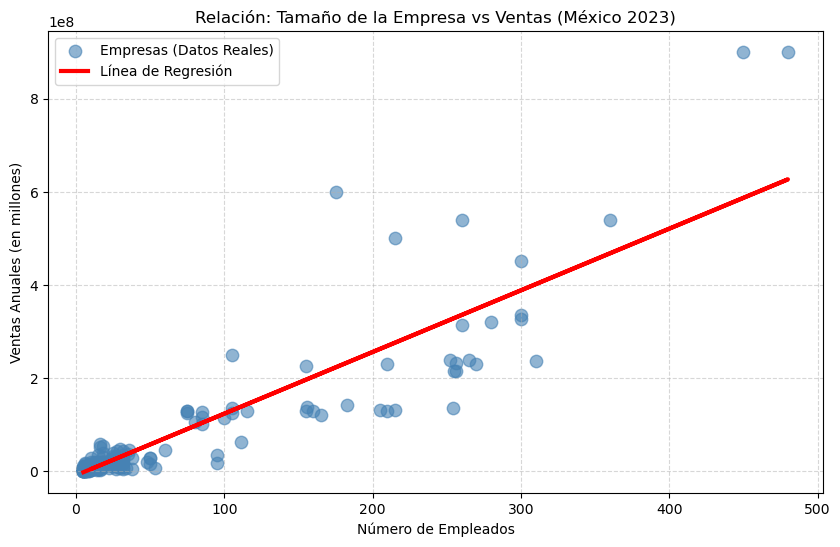

In [23]:
plt.figure(figsize=(10,6))
plt.scatter(X, y, color='steelblue', s=80, label='Empresas (Datos Reales)', alpha=0.6)
plt.plot(X, y_pred, color='red', linewidth=3, label='Línea de Regresión')
plt.xlabel('Número de Empleados')
plt.ylabel('Ventas Anuales (en millones)')
plt.title('Relación: Tamaño de la Empresa vs Ventas (México 2023)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## Conclusion ##

**¿qué variables explican mejor las ventas o la productividad de una empresa?**
